In [ ]:

!wget https://zenodo.org/record/4068196/files/mridangam_stroke_1.5.zip?download=1 -O mridangam_dataset.zip


!unzip -q mridangam_dataset.zip -d mridangam_stroke_dataset/


!rm mridangam_dataset.zip

print("Dataset ready!")

--2026-04-02 21:40:17--  https://zenodo.org/record/4068196/files/mridangam_stroke_1.5.zip?download=1
Resolving zenodo.org (zenodo.org)... 137.138.52.235, 188.184.98.114, 137.138.153.219, ...
Connecting to zenodo.org (zenodo.org)|137.138.52.235|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/4068196/files/mridangam_stroke_1.5.zip [following]
--2026-04-02 21:40:17--  https://zenodo.org/records/4068196/files/mridangam_stroke_1.5.zip
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 130280712 (124M) [application/octet-stream]
Saving to: ‘mridangam_dataset.zip’

mridangam_dataset.z 100%[===================>] 124.25M  12.5MB/s    in 11s     

2026-04-02 21:40:29 (11.3 MB/s) - ‘mridangam_dataset.zip’ saved [130280712/130280712]

replace mridangam_stroke_dataset/__MACOSX/._mridangam_stroke_1.5? [y]es, [n]o, [A]ll, [N]one, [r]ename: Dataset ready!


In [ ]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras import layers, models


BASE_PATH = "mridangam_stroke_dataset/mridangam_stroke_1.5/"


categories = [d for d in os.listdir(BASE_PATH) if os.path.isdir(os.path.join(BASE_PATH, d))]
print(f"Pitch categories found: {categories}")

Stroke categories found: ['D#', 'E', 'C#', 'B', 'C', 'D']


In [ ]:
def extract_spectrogram_fixed(file_path, target_width=64):

    audio, sr = librosa.load(file_path, sr=22050)
    audio, _ = librosa.effects.trim(audio)

    # Generate Mel Spectrogram
    spectrogram = librosa.feature.melspectrogram(
        y=audio, sr=sr, n_mels=128, hop_length=256, n_fft=1024
    )
    spectrogram_db = librosa.power_to_db(spectrogram, ref=np.max)

    # Pad or truncate to ensure width is exactly 64
    if spectrogram_db.shape[1] < target_width:
        pad_width = target_width - spectrogram_db.shape[1]
        spectrogram_db = np.pad(spectrogram_db, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        spectrogram_db = spectrogram_db[:, :target_width]

    return spectrogram_db

X_spec = []
y_spec = []

print("Extracting Spectrograms")
for stroke in categories:
    stroke_folder = os.path.join(BASE_PATH, stroke)
    for file_name in os.listdir(stroke_folder):
        if file_name.endswith('.wav'):
            feat = extract_spectrogram_fixed(os.path.join(stroke_folder, file_name))
            X_spec.append(feat)
            y_spec.append(stroke)



Extracting Spectrograms... this may take 2-3 minutes.


In [ ]:
# Convert to 4D array: (Samples, Height, Width, Channels)
X_spec = np.array(X_spec)
X_spec = X_spec.reshape(X_spec.shape[0], 128, 64, 1)

# Encode Labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_spec)
num_classes = len(le.classes_)

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X_spec, y_encoded, test_size=0.2, random_state=42)
print("Data prepared with shape:", X_train.shape) # Should be (Samples, 128, 64, 1)

In [ ]:
def build_mridangam_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Block 1: Basic Spectral Shapes
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Block 2: Complex Textures
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Block 3: High-level harmonic features
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5), # Crucial for 90%+ accuracy [cite: 102]
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model_2d = build_mridangam_cnn((128, 64, 1), num_classes)
model_2d.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.2835 - loss: 2.1620 - val_accuracy: 0.4040 - val_loss: 1.5174 - learning_rate: 0.0010
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5289 - loss: 1.1806 - val_accuracy: 0.7787 - val_loss: 0.7801 - learning_rate: 0.0010
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7106 - loss: 0.7092 - val_accuracy: 0.9362 - val_loss: 0.2559 - learning_rate: 0.0010
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8257 - loss: 0.4657 - val_accuracy: 0.9262 - val_loss: 0.2750 - learning_rate: 0.0010
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8930 - loss: 0.3087 - val_accuracy: 0.9778 - val_loss: 0.1010 - learning_rate: 0.0010
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9366 - loss: 0.1824 - val_accuracy: 0.9456 - val_loss: 0.1629 - learning_rate: 0.0010
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9477 - loss: 0

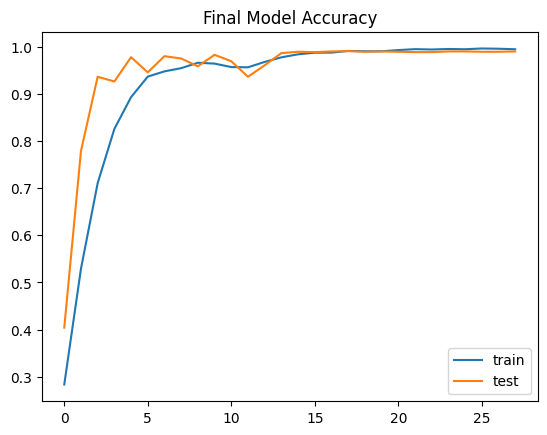

In [ ]:
# Callbacks for optimization
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

history = model_2d.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[reduce_lr, early_stop]
)

# Plot Results
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.title('Final Model Accuracy')
plt.legend()
plt.show()

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


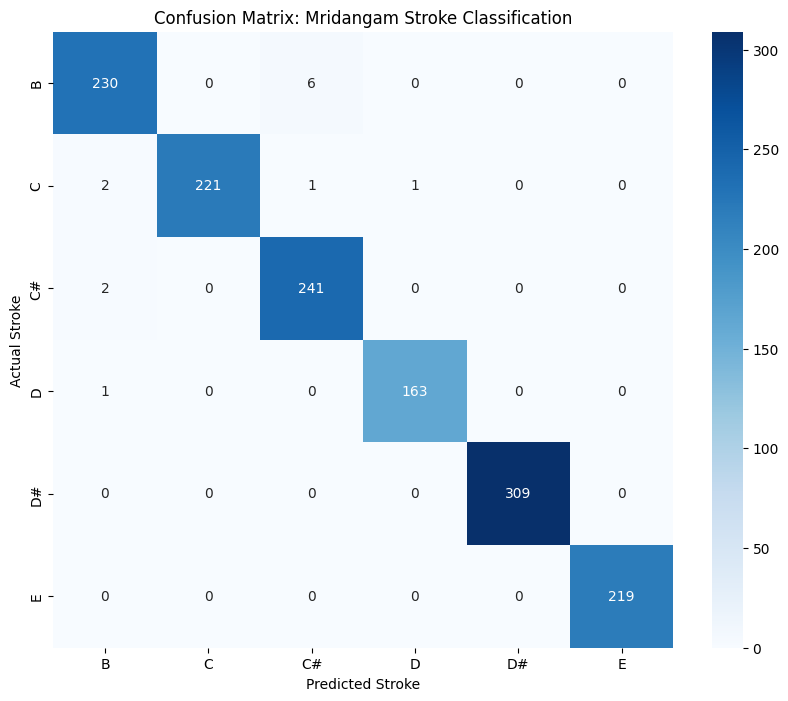


Detailed Classification Report:

              precision    recall  f1-score   support

           B       0.98      0.97      0.98       236
           C       1.00      0.98      0.99       225
          C#       0.97      0.99      0.98       243
           D       0.99      0.99      0.99       164
          D#       1.00      1.00      1.00       309
           E       1.00      1.00      1.00       219

    accuracy                           0.99      1396
   macro avg       0.99      0.99      0.99      1396
weighted avg       0.99      0.99      0.99      1396



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Get model predictions for the entire test set
y_pred_probs = model_2d.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# 2. Generate the confusion matrix
# y_test are the true labels, y_pred_classes are the predicted labels
cm = confusion_matrix(y_test, y_pred_classes)

# 3. Plot the confusion matrix using Seaborn for a "professional" look
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix: Mridangam Pitch Classification')
plt.xlabel('Predicted Pitch')
plt.ylabel('Actual Pitch')
plt.show()

# 4. Print a detailed classification report (Precision, Recall, F1-Score)
print("\nDetailed Classification Report:\n")
print(classification_report(y_test, y_pred_classes, target_names=le.classes_))

In [ ]:
# 1. Ensure the system can read phone audio formats
!apt-get install -y ffmpeg libavcodec-extra -qq

from google.colab import files
import librosa
import numpy as np

# 2. Upload your file
print("Select your Mridangam recording (.mp4, .m4a, .wav, or .mp3):")
uploaded = files.upload()

for filename in uploaded.keys():
    try:
        # 3. Load and Normalize Audio
        # librosa handles the mp4 extraction automatically
        audio, sr = librosa.load(filename, sr=22050)
        audio = librosa.util.normalize(audio)
        audio, _ = librosa.effects.trim(audio)

        # 4. Convert to Spectrogram (Matching model input)
        spectrogram = librosa.feature.melspectrogram(
            y=audio, sr=sr, n_mels=128, hop_length=256, n_fft=1024
        )
        spectrogram_db = librosa.power_to_db(spectrogram, ref=np.max)

        # Ensure the width is exactly 64 pixels
        target_width = 64
        if spectrogram_db.shape[1] < target_width:
            pad_width = target_width - spectrogram_db.shape[1]
            feat = np.pad(spectrogram_db, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            feat = spectrogram_db[:, :target_width]

        # 5. Predict
        feat = feat.reshape(1, 128, 64, 1)
        preds = model_2d.predict(feat, verbose=0) # verbose=0 keeps output clean

        # 6. Results
        class_idx = np.argmax(preds)
        predicted_label = le.inverse_transform([class_idx])[0]
        confidence = np.max(preds) * 100

        print(f"\n File: {filename}")
        print(f"Prediction: {predicted_label}")
        print(f"Confidence: {confidence:.2f}%")
        print("-" * 30)

    except Exception as e:
        print(f"❌ Error with {filename}: {e}")

Select your Mridangam recording (.mp4, .m4a, .wav, or .mp3):


Saving try classification.mp4 to try classification (3).mp4


/tmp/ipykernel_5820/3874821076.py:16: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(filename, sr=22050)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)



✅ File: try classification (3).mp4
🎯 Prediction: C#
📊 Confidence: 100.00%
------------------------------
